#### Description:

In [1]:
'''
    I aim to Build a Model That Predicat the salary based on:
        (city, occupation, field, years_of_experience, employment_type, education_level, gender, company_size)
'''

'\n    I aim to Build a Model That Predicat the salary based on:\n        (city, occupation, field, years_of_experience, employment_type, education_level, gender, company_size)\n'

#### Import Data and Select Features

In [2]:
# Import Packages
import pandas as pd

In [3]:
# %ls drive/MyDrive/job_market_dataset.csv
# data = pd.read_csv("drive/MyDrive/job_market_dataset.csv")
data = pd.read_csv("./data/job_market_dataset.csv")
data.head(2)

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5


In [4]:
# Delete Features (year, month)
cp_data = data.drop(["year", "month"], axis=1)
cp_data = cp_data.iloc[:10000]
cp_data.head(4)

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large


#### Feature Encoding 

In [5]:
from sklearn.preprocessing import LabelEncoder # for Mapping / Label Encoder
from sklearn.preprocessing import OneHotEncoder # for One Hot Encoding

In [6]:
# Mapping/Label Encoding This Varaibles
company_size_map = {'Large': 3, 'Enterprise': 2, 'Medium': 1, 'Small': 0}
cp_data["company_size"] = [company_size_map[v] for v in cp_data["company_size"]]

gender_map = {'Male': 0, 'Female': 1, 'Other': 2}
cp_data["gender"] = [gender_map[v] for v in cp_data["gender"]]

education_level_map = {'PhD': 3, 'Master': 2, 'Bachelor': 1, 'High School': 0}
cp_data["education_level"] = [education_level_map[v] for v in cp_data["education_level"]]

# One-Hot-Encoding
one_hot_encoder = OneHotEncoder()
cp_data = pd.get_dummies(cp_data, columns=["field", "employment_type", "city", "country", "occupation"])
cp_data.head(3)

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,...,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
0,16,359609.0,2,0,3,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,12,79059.0,3,0,3,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,10,258077.0,2,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


#### Split Data

In [7]:
# Get X and y
X = cp_data.drop("salary", axis=1)
y = cp_data["salary"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# Split Train Set, Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Data Normalisation

In [10]:
cp_data.head(4)

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,...,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
0,16,359609.0,2,0,3,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,12,79059.0,3,0,3,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,10,258077.0,2,0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,7,252282.0,2,1,3,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [11]:
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from copy import deepcopy

In [12]:
max_scaled_dataset = deepcopy(cp_data)

In [13]:
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
cols = max_scaled_dataset.columns
for col in cols:
       max_scaled_dataset[col] = max_scaled_dataset[col] / int(max_scaled_dataset[col].max())

max_scaled_dataset.describe()

,years_of_experience,salary,education_level,gender,company_size,field_Business,field_Design,field_Finance,field_Human Resources,field_Marketing,...,occupation_Cloud Engineer,occupation_Data Analyst,occupation_Data Scientist,occupation_Financial Analyst,occupation_HR Analyst,occupation_Marketing Specialist,occupation_Operations Manager,occupation_Product Manager,occupation_Software Engineer,occupation_UX Designer
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.476812,0.555776,0.496000,0.500950,0.492900,0.082700,0.086600,0.08260,0.082700,0.083300,...,0.083100,0.087400,0.082200,0.08260,0.082700,0.083300,0.077100,0.085000,0.081300,0.086600
std,0.287030,0.229590,0.372466,0.407174,0.370985,0.275442,0.281262,0.27529,0.275442,0.276349,...,0.276047,0.282434,0.274683,0.27529,0.275442,0.276349,0.266763,0.278896,0.273309,0.281262
min,0.000000,0.034176,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.240000,0.384732,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.480000,0.537282,0.333333,0.500000,0.333333,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.720000,0.714824,0.666667,1.000000,0.666667,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Model Building (Random Forest)

In [14]:
from sklearn.ensemble import RandomForestRegressor

In [15]:
# Build a Model
model = RandomForestRegressor(n_estimators=100, oob_score=True)

In [16]:
# Fit Training Set with prediction result
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
# Prediction
y_pred = model.predict(X_test)

In [18]:
# Get Test Dataset Frame
y_test_df = pd.DataFrame(y_test, columns=["salary"])
y_test_df.reset_index(inplace=True)
y_test_df = y_test_df.drop("index", axis=1)
y_test_df.head(3)

,salary
0,173005.0
1,161253.0
2,370000.0


In [19]:
# Get Predction DataSet Frame
y_pred_df = pd.DataFrame(y_pred, columns=["salary_pred"])
y_pred_df.head(3)

,salary_pred
0,192157.49
1,205840.96
2,364350.74


In [20]:
# Combine The Two DataSet
y_pred_real_df = pd.concat([y_pred_df, y_test_df], axis=1)
y_pred_real_df.head(3)

,salary_pred,salary
0,192157.49,173005.0
1,205840.96,161253.0
2,364350.74,370000.0


#### Model Improvements

In [21]:
'''
    - MAE (Mean Absolute Error) → average difference
    - RMSE (Root Mean Squared Error) → penalizes big errors
    - Residual
    - R² → % of variance explained by model
    - Feature Importance: mesure how much each feature combined to the model
    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV
    - Result Visualisation
'''

'\n    - MAE (Mean Absolute Error) → average difference\n    - RMSE (Root Mean Squared Error) → penalizes big errors\n    - Residual\n    - R² → % of variance explained by model\n    - Feature Importance: mesure how much each feature combined to the model\n    - Update The Model Paramters like (n_estimators, max_depth, max_features, ...) WITH GridSearchCV\n    - Result Visualisation\n'

In [22]:
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, r2_score as r_2
from math import sqrt
import matplotlib.pyplot as plt

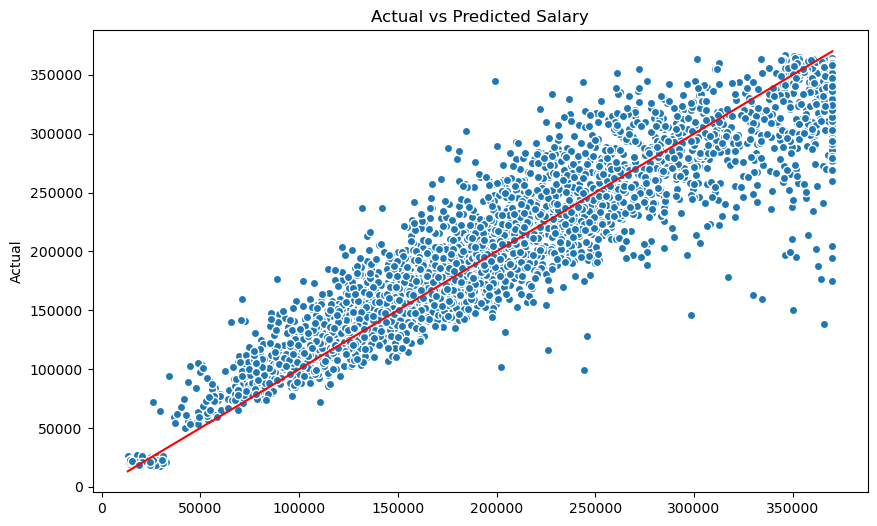

In [41]:
# Visualizing The Regression Results: Predicted vs Actual Visualtion
# FROM: https://codesignal.com/learn/courses/regression-analysis-to-model-diamond-prices/lessons/visualizing-actual-vs-predicted-prices-in-regression-models

plt.figure(figsize=(10, 6))

# Add Scatter For Visuale The Points
plt.scatter(y_test, y_pred, edgecolors="w")
plt.ylabel("Prediction")
plt.ylabel("Actual")
plt.title('Actual vs Predicted Salary')

# Visuale The Line For The Prefect Prediction
limits = [y_test.min(), y_test.max()]
plt.plot(limits, limits, color="red", linestyle="-", ) # draw line with coordinate (x1, y1) and (x2, y2)


In [23]:
# Get Mean Absolute Error (MAE)
mae_val = sum(abs(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"])) / y_pred_real_df["salary"].size
print(mae_val)
mae(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

26082.818260055556


26082.818260055563

In [24]:
# Root Mean Squared Error (RMSE)
rmse_val = sqrt(sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / y_test.count())
print(rmse_val)
rmse(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

35212.50539195765


35212.50539195765

In [25]:
# Get R²
mean_y_test_set = y_test.mean()
r_2_val = 1 - (sum(pow(y_pred_real_df["salary"] - y_pred_real_df["salary_pred"], 2)) / sum(pow(y_pred_real_df["salary"] - mean_y_test_set, 2)))
print(r_2_val)

r_2(y_pred=y_pred_real_df["salary_pred"], y_true=y_pred_real_df["salary"])

0.8316651129172163


0.8316651129172163

In [27]:
residual = y_test - y_pred
residual

6252   -19152.49
4684   -44587.96
1731     5649.26
4742    12459.10
4521    35468.97
          ...   
8014     6594.32
1074    40791.99
3063    -7458.45
6487    10185.34
4705      331.12
Name: salary, Length: 3000, dtype: float64

{'years_of_experience': 0.20975544465810622, 'education_level': 0.12488271870274559, 'gender': 0.011161485327495675, 'company_size': 0.08143044269350584, 'field_Business': 0.0009397930382365214, 'field_Design': 0.0010974873531254955, 'field_Finance': 0.0015926622722851273, 'field_Human Resources': 0.011613829032966577, 'field_Marketing': 0.006859584908965194, 'field_Operations': 0.0038088073306823396, 'field_Technology': 0.08291969116321106, 'employment_type_freelance': 0.005469164405689945, 'employment_type_full_time': 0.004450721193931903, 'employment_type_internship': 0.02465606379702168, 'employment_type_part_time': 0.005758513711339564, 'employment_type_work_from_home': 0.00446642086877459, 'city_Amsterdam': 0.001012447945205307, 'city_Auckland': 0.0031089421764935437, 'city_Bangalore': 0.052579592278412225, 'city_Berlin': 0.0017356169185194308, 'city_Cape Town': 0.02633509459935984, 'city_Dubai': 0.0032678377769445504, 'city_Dublin': 0.0008703353109515165, 'city_London': 0.001325

<BarContainer object of 71 artists>

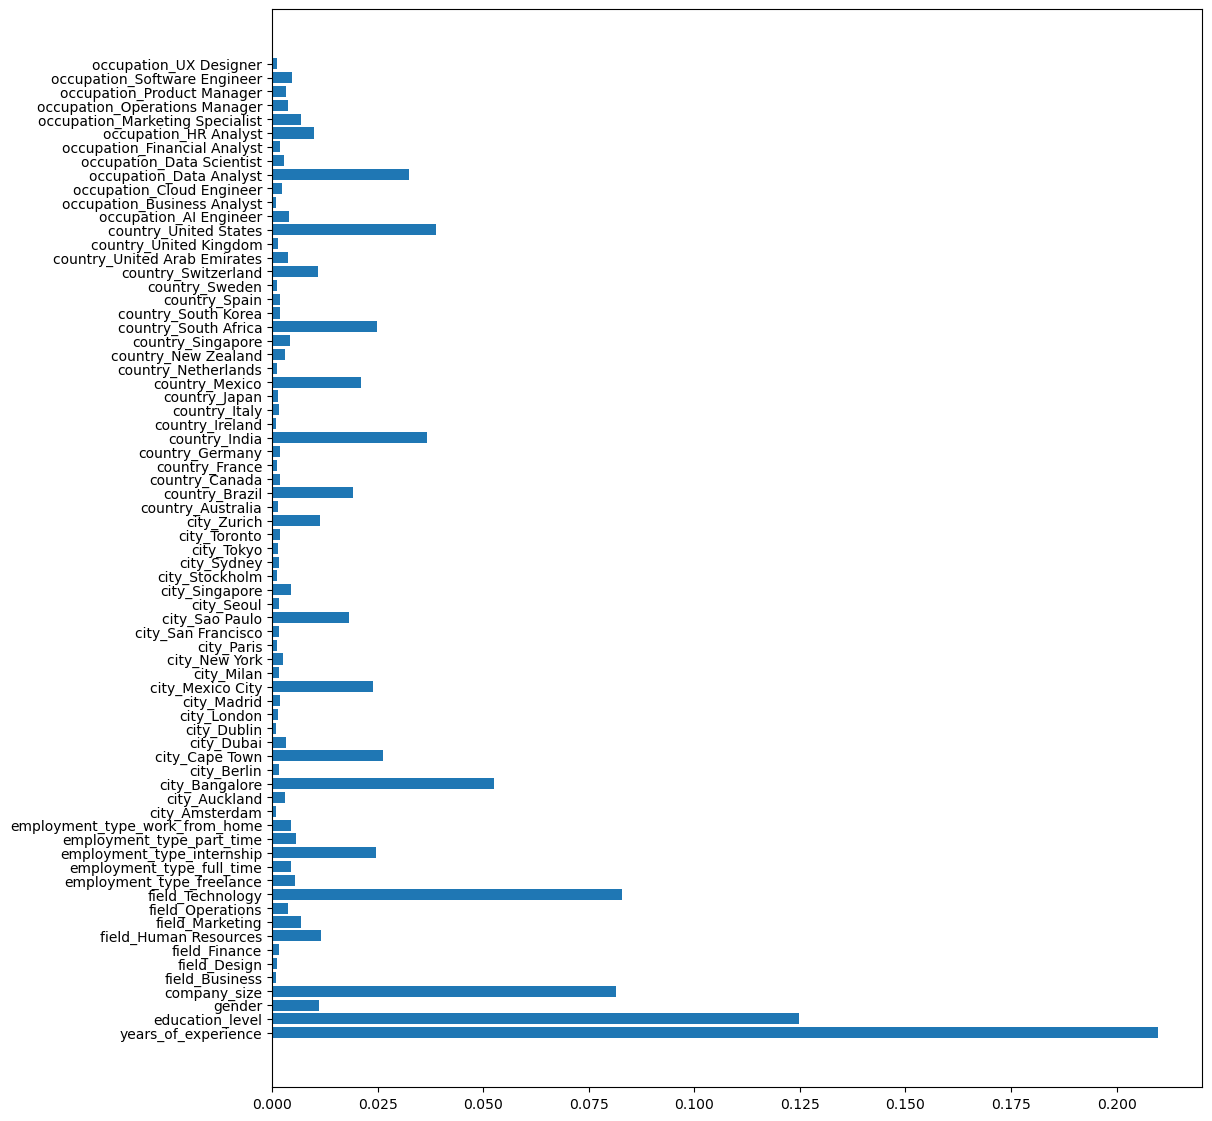

In [ ]:
# Features Importance
features_names = model.feature_names_in_
features_importances = model.feature_importances_
dic_f = {}
for i in range(len(features_names)):
    dic_f[features_names[i]] = features_importances[i]
print(dic_f)

# Visuale The Feature Importance
plt.figure(figsize=(12, 14))
plt.barh(features_names, features_importances)